# GAN のスクラッチ

In [1]:
import tensorflow as tf
print(tf.__version__)

2024-10-27 08:58:17.445648: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-27 08:58:17.452527: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-27 08:58:17.460942: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-27 08:58:17.463430: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-27 08:58:17.470128: I tensorflow/core/platform/cpu_feature_guar

2.17.0


In [3]:
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
if tf.config.list_physical_devices('GPU'):
    device_name = tf.test.gpu_device_name()
else:
    device_name = '/CPU:0'
print(device_name)

/device:GPU:0


I0000 00:00:1729987281.656595   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729987281.656657   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729987281.656670   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729987281.771686   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729987281.771732   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-27

## 生成器と識別機を実装する
- それぞれ1つ以上の隠れ層をもつ2つの全結合ネットワークとして定義する（オリジナルのGAN: vanilla GAN）

In [5]:
import tensorflow_datasets as tfds
import numpy as np

In [6]:
def make_generator_network(num_hidden_layers=1, num_hidden_units=100,
                           num_output_units=784):
    model = tf.keras.Sequential()
    for i in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(units=num_hidden_units, use_bias=False))
        model.add(tf.keras.layers.LeakyReLU())
        model.add(tf.keras.layers.Dense(units=num_output_units, activation='tanh'))
    return model

def make_discriminator_network(num_hidden_layers=1, num_hidden_units=100,
                            num_output_units=784):
    model = tf.keras.Sequential()
    for i in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(units=num_hidden_units))
        model.add(tf.keras.layers.LeakyReLU())
        model.add(tf.keras.layers.Dropout(rate=0.5))

    model.add(tf.keras.layers.Dense(units=num_output_units, activation=None))
    return model


In [7]:
image_size = (28,28)
z_size = 20
mode_z = 'uniform'
gen_hidden_layers = 1
gen_hidden_size = 100
disc_hidden_layers = 1
disc_hidden_size = 100
tf.random.set_seed(1)

gen_model = make_generator_network(num_hidden_layers=gen_hidden_layers,
                                   num_hidden_units=gen_hidden_size,
                                   num_output_units=np.prod(image_size))
gen_model.build(input_shape=(None, z_size))
gen_model.summary()

I0000 00:00:1729988172.984136   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729988172.984201   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729988172.984213   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1729988172.984376   13198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-27 09:16:12.984396: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2112] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        79,184 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,184 (317.12 KB)

 Trainable params: 81,184 (317.12 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
disc_model = make_discriminator_network(num_hidden_layers=disc_hidden_layers,
                                        num_hidden_units=disc_hidden_size,
                                        )
disc_model.build(input_shape=(None, np.prod(image_size)))
disc_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        79,184 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,684 (615.95 KB)

 Trainable params: 157,684 (615.95 KB)

 Non-trainable params: 0 (0.00 B)

## 訓練データの定義
- 生成器の出力層は tanh関数を活性化関数に用いるため出力は -1~1 となる。これに対して MNIST は 0~255 であるので、型変換する。

In [9]:
mnist_bldr = tfds.builder('mnist')
mnist_bldr.download_and_prepare()
mnist = mnist_bldr.as_dataset(shuffle_files=False)

def preprocess(ex, mode='uniform'):
    image =  ex['image']
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.reshape(image, [-1])
    image = image*2 - 1.0
    if mode == 'uniform':
        input_z = tf.random.uniform(shape=(z_size,), minval=-1.0, maxval=1.0)
    elif mode == 'normal':
        input_z = tf.random.normal(shape=(z_size,))
    return input_z, image


In [10]:
mnist_trainset = mnist['train']
mnist_trainset = mnist_trainset.map(preprocess)

In [12]:
# 確認
mnist_trainset = mnist_trainset.batch(32, drop_remainder=True)
input_z, input_real = next(iter(mnist_trainset))
print('input-z -- shape: ', input_z.shape)
print('input-real -- shape: ', input_real.shape)

input-z -- shape:  (32, 20)
input-real -- shape:  (32, 784)


2024-10-27 09:42:30.774560: W tensorflow/core/kernels/data/cache_dataset_ops.cc:913] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [13]:
g_output = gen_model(input_z)
print('Output of G -- shape: ', g_output.shape)

Output of G -- shape:  (32, 784)


In [14]:
d_logits_real = disc_model(input_real)
d_logits_fake = disc_model(g_output)
print('Disc. (real) -- shape: ', d_logits_real.shape)
print('Disc. (fake) -- shape: ', d_logits_fake.shape)

Disc. (real) -- shape:  (32, 784)
Disc. (fake) -- shape:  (32, 784)


## GAN の訓練

In [16]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)

g_labels_real = tf.ones_like(d_logits_fake)
g_loss = loss_fn(y_true=g_labels_real, y_pred=d_logits_fake)
print(f'Generator Loss: {g_loss:.4f}')

Generator Loss: 0.6939


In [17]:
d_labels_real = tf.ones_like(d_logits_real)
d_labels_fake = tf.zeros_like(d_logits_fake)
d_loss_real = loss_fn(y_true=d_labels_real, y_pred=d_logits_real)
d_loss_fake = loss_fn(y_true=d_labels_fake, y_pred=d_logits_fake)
print(f'Discriminator Losses: Real {d_loss_real.numpy():.4f} Fake {d_loss_fake.numpy():.4f}')

Discriminator Losses: Real 0.7185 Fake 0.6932


In [18]:
import time 

num_epochs = 100
batch_size = 64
image_size = (28, 28)
z_size = 20
mode_z = 'uniform'
gen_hidden_layers = 1
gen_hidden_size = 100
disc_hidden_layers = 1
disc_hidden_size = 100

tf.random.set_seed(1)
np.random.seed(1)

if mode_z == 'uniform':
    fixed_z = tf.random.uniform(shape=(batch_size, z_size), minval=-1, maxval=1)
elif mode_z == 'normal':
    fixed_z = tf.random.normal(shape=(batch_size, z_size))

def create_samples(g_model, input_z):
    g_output = g_model(input_z, training=False)
    images = tf.reshape(g_output, (batch_size, *image_size))
    return (images+1)/2.0

# datasets
mnist_trainset = mnist['train']
mnist_trainset = mnist_trainset.map(lambda ex: preprocess(ex, mode=mode_z))
mnist_trainset = mnist_trainset.shuffle(10000)
mnist_trainset = mnist_trainset.batch(batch_size, drop_remainder=True)

In [19]:
# modeling
with tf.device(device_name):
    gen_model = make_generator_network(num_hidden_layers=gen_hidden_layers,
                                       num_hidden_units=gen_hidden_size,
                                       num_output_units=np.prod(image_size))
    gen_model.build(input_shape=(None, z_size))
    disc_model = make_discriminator_network(num_hidden_layers=disc_hidden_layers,
                                            num_hidden_units=disc_hidden_size)
    disc_model.build(input_shape=(None, np.prod(image_size)))

In [21]:
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)
g_optimizer = tf.keras.optimizers.Adam()
d_optimizer = tf.keras.optimizers.Adam()

all_losses = []
all_d_vals = []
epoch_samples = []

start_time = time.time()
for epoch in range(1, num_epochs+1):
    epoch_losses, epoch_d_vals = [], []
    for i, (input_z, input_real) in enumerate(mnist_trainset):
        # g loss calc
        with tf.GradientTape() as g_tape:
            g_output = gen_model(input_z)
            d_logits_fake = disc_model(g_output, training=True)
            labels_real = tf.ones_like(d_logits_fake)
            g_loss = loss_fn(y_true=labels_real, y_pred=d_logits_fake)

        # g loss gradient calc
        g_grads = g_tape.gradient(g_loss, gen_model.trainable_variables)
        g_optimizer.apply_gradients(grads_and_vars=zip(g_grads,
                                                       gen_model.trainable_variables))
        
        # d loss cals
        with tf.GradientTape() as d_tape:
            d_logits_real = disc_model(input_real, training=True)
            d_labels_real = tf.ones_like(d_logits_real)
            d_loss_real = loss_fn(y_true=d_labels_real, y_pred=d_logits_real)
            d_logits_fake = disc_model(g_output, training=True)
            d_labels_fake = tf.zeros_like(d_logits_fake)
            d_loss_fake = loss_fn(y_true=d_labels_fake, y_pred=d_logits_fake)
            d_loss = d_loss_real + d_loss_fake

        # d loss gradient calc
        d_grads = d_tape.gradient(d_loss, disc_model.trainable_variables)
        d_optimizer.apply_gradients(grads_and_vars=zip(d_grads, disc_model.trainable_variables))

        epoch_losses.append((g_loss.numpy(), d_loss.numpy(), d_loss_real.numpy(), d_loss_fake.numpy()))
        d_probs_real = tf.reduce_mean(tf.sigmoid(d_logits_real))
        d_probs_fake = tf.reduce_mean(tf.sigmoid(d_logits_fake))
        epoch_d_vals.append((d_probs_real.numpy(), d_probs_fake.numpy()))
    
    all_losses.append(epoch_losses)
    all_d_vals.append(epoch_d_vals)
    print(f'Epoch {epoch:03d} | ET {(time.time() - start_time)/60:.2f} | Avg Losses >> G/D {list(np.mean(all_losses[-1], axis=0))[0]:.4f}/{list(np.mean(all_losses[-1], axis=0))[1]:.4f} [D-Real: {list(np.mean(all_losses[-1], axis=0))[2]:.4f} D-Fake: {list(np.mean(all_losses[-1], axis=0))[3]:.4f}]')
    epoch_samples.append(create_samples(gen_model, fixed_z).numpy())

2024-10-27 10:32:26.757824: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 001 | ET 0.57 | Avg Losses >> G/D 2.8653/0.3052 [D-Real: 0.0539 D-Fake: 0.2513]


2024-10-27 10:33:03.596122: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 002 | ET 1.25 | Avg Losses >> G/D 4.9000/0.4475 [D-Real: 0.1762 D-Fake: 0.2713]
Epoch 003 | ET 1.87 | Avg Losses >> G/D 2.9287/0.8060 [D-Real: 0.3697 D-Fake: 0.4363]


2024-10-27 10:34:24.397873: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Epoch 016 | ET 9.96 | Avg Losses >> G/D 1.1359/1.1931 [D-Real: 0.6181 D-Fake: 0.5750]
Epoch 017 | ET 10.56 | Avg Losses >> G/D 1.1741/1.1681 [D-Real: 0.6084 D-Fake: 0.5596]
Epoch 018 | ET 11.18 | Avg Losses >> G/D 1.1578/1.1707 [D-Real: 0.6076 D-Fake: 0.5630]
Epoch 019 | ET 11.81 | Avg Losses >> G/D 1.1457/1.1929 [D-Real: 0.6150 D-Fake: 0.5778]
Epoch 020 | ET 12.40 | Avg Losses >> G/D 1.1231/1.1901 [D-Real: 0.6147 D-Fake: 0.5754]
Epoch 021 | ET 12.97 | Avg Losses >> G/D 1.0674/1.2387 [D-Real: 0.6306 D-Fake: 0.6081]
Epoch 022 | ET 13.63 | Avg Losses >> G/D 1.1332/1.1853 [D-Real: 0.6105 D-Fake: 0.5748]
Epoch 023 | ET 14.28 | Avg Losses >> G/D 1.1009/1.2054 [D-Real: 0.6189 D-Fake: 0.5865]
Epoch 024 | ET 14.87 | Avg Losses >> G/D 1.0345/1.2416 [D-Real: 0.6356 D-Fake: 0.6060]
Epoch 025 | ET 15.55 | Avg Losses >> G/D 1.0735/1.2271 [D-Real: 0.6243 D-Fake: 0.6028]
Epoch 026 | ET 16.18 | Avg Losses >> G/D 1.0649/1.2068 [D-Real: 0.6192 D-Fake: 0.5876]
Epoch 027 | ET 16.77 | Avg Losses >> G/D 1.0

2024-10-27 10:51:41.816632: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 032 | ET 19.82 | Avg Losses >> G/D 1.0354/1.2236 [D-Real: 0.6220 D-Fake: 0.6017]
Epoch 033 | ET 20.48 | Avg Losses >> G/D 0.9343/1.2841 [D-Real: 0.6486 D-Fake: 0.6355]
Epoch 034 | ET 21.08 | Avg Losses >> G/D 1.0282/1.2630 [D-Real: 0.6366 D-Fake: 0.6264]
Epoch 035 | ET 21.72 | Avg Losses >> G/D 1.0976/1.2375 [D-Real: 0.6243 D-Fake: 0.6132]
Epoch 036 | ET 22.33 | Avg Losses >> G/D 1.0294/1.2338 [D-Real: 0.6261 D-Fake: 0.6078]
Epoch 037 | ET 22.91 | Avg Losses >> G/D 0.9413/1.2610 [D-Real: 0.6396 D-Fake: 0.6214]
Epoch 038 | ET 23.54 | Avg Losses >> G/D 0.9575/1.2903 [D-Real: 0.6483 D-Fake: 0.6419]
Epoch 039 | ET 24.14 | Avg Losses >> G/D 1.0230/1.2623 [D-Real: 0.6368 D-Fake: 0.6255]
Epoch 040 | ET 24.72 | Avg Losses >> G/D 1.0051/1.2704 [D-Real: 0.6408 D-Fake: 0.6295]
Epoch 041 | ET 25.38 | Avg Losses >> G/D 0.9658/1.2681 [D-Real: 0.6385 D-Fake: 0.6296]
Epoch 042 | ET 25.99 | Avg Losses >> G/D 0.9648/1.2811 [D-Real: 0.6445 D-Fake: 0.6366]
Epoch 043 | ET 26.64 | Avg Losses >> G/D 0.

2024-10-27 11:11:25.817540: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 064 | ET 39.56 | Avg Losses >> G/D 0.8949/1.3139 [D-Real: 0.6603 D-Fake: 0.6536]
Epoch 065 | ET 40.17 | Avg Losses >> G/D 0.9659/1.3001 [D-Real: 0.6522 D-Fake: 0.6478]
Epoch 066 | ET 40.75 | Avg Losses >> G/D 0.9155/1.3036 [D-Real: 0.6527 D-Fake: 0.6508]
Epoch 067 | ET 41.38 | Avg Losses >> G/D 0.9138/1.3039 [D-Real: 0.6559 D-Fake: 0.6480]
Epoch 068 | ET 41.97 | Avg Losses >> G/D 0.9633/1.2910 [D-Real: 0.6484 D-Fake: 0.6426]
Epoch 069 | ET 42.55 | Avg Losses >> G/D 0.9083/1.3036 [D-Real: 0.6574 D-Fake: 0.6463]
Epoch 070 | ET 43.15 | Avg Losses >> G/D 0.9126/1.3266 [D-Real: 0.6644 D-Fake: 0.6622]
Epoch 071 | ET 43.78 | Avg Losses >> G/D 0.9416/1.3046 [D-Real: 0.6531 D-Fake: 0.6515]
Epoch 072 | ET 44.42 | Avg Losses >> G/D 0.8954/1.3173 [D-Real: 0.6619 D-Fake: 0.6554]
Epoch 073 | ET 45.01 | Avg Losses >> G/D 0.9402/1.3115 [D-Real: 0.6569 D-Fake: 0.6545]
Epoch 074 | ET 45.69 | Avg Losses >> G/D 0.8968/1.3168 [D-Real: 0.6620 D-Fake: 0.6548]
Epoch 075 | ET 46.30 | Avg Losses >> G/D 0.

In [22]:
import itertools
import matplotlib.pyplot as plt

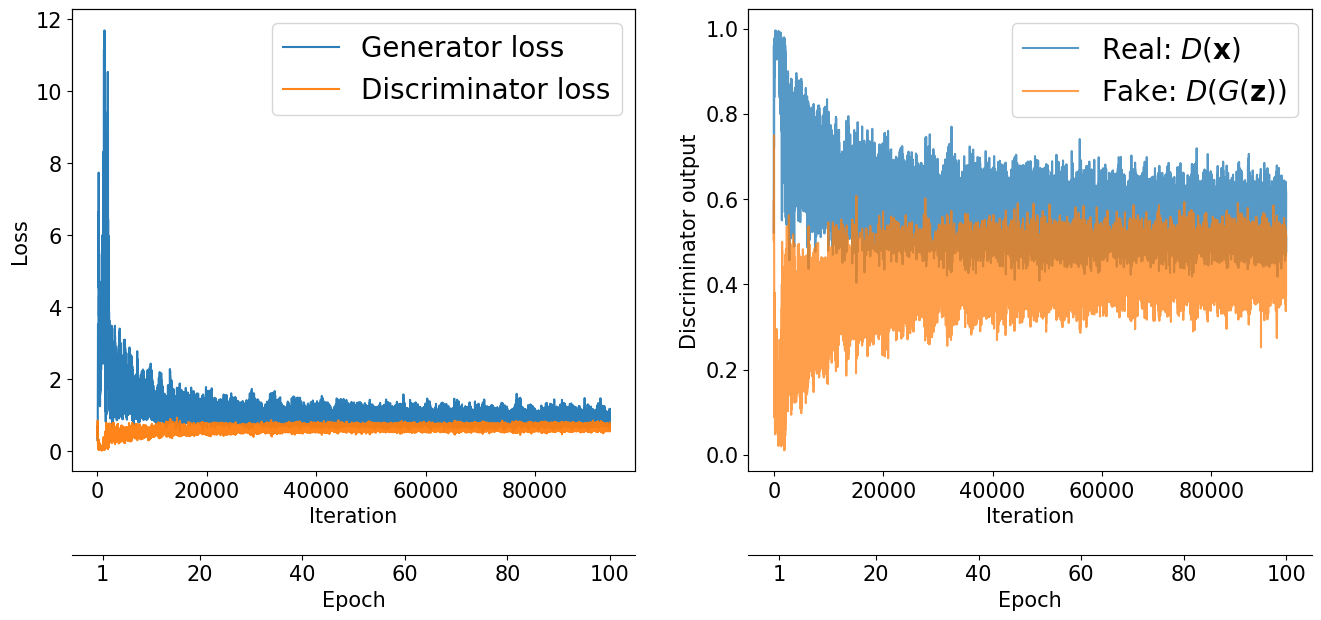

In [24]:
fig = plt.figure(figsize=(16, 6))

ax = fig.add_subplot(1, 2, 1)
g_losses = [item[0] for item in itertools.chain(*all_losses)]
d_losses = [item[1]/2.0 for item in itertools.chain(*all_losses)]
plt.plot(g_losses, label='Generator loss', alpha=0.95)
plt.plot(d_losses, label='Discriminator loss', alpha=0.95)
plt.legend(fontsize=20)
ax.set_xlabel('Iteration', size=15)
ax.set_ylabel('Loss', size=15)

epochs = np.arange(1, 101)
epoch2iter = lambda e: e*len(all_losses[-1])
epoch_ticks = (1, 20, 40, 60, 80, 100)
newpos = [epoch2iter(e) for e in epoch_ticks]
ax2 = ax.twiny()
ax2.set_xticks(newpos)
ax2.set_xticklabels(epoch_ticks)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 60))
ax2.set_xlabel('Epoch', size=15)
ax2.set_xlim(ax.get_xlim())
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
d_vals_real = [item[0] for item in itertools.chain(*all_d_vals)]
d_vals_fake = [item[1] for item in itertools.chain(*all_d_vals)]
plt.plot(d_vals_real, alpha=0.75, label=r'Real: $D(\mathbf{x})$')
plt.plot(d_vals_fake, alpha=0.75, label=r'Fake: $D(G(\mathbf{z}))$')
plt.legend(fontsize=20)
ax.set_xlabel('Iteration', size=15)
ax.set_ylabel('Discriminator output', size=15)

ax2 = ax.twiny()
ax2.set_xticks(newpos)
ax2.set_xticklabels(epoch_ticks)
ax2.xaxis.set_ticks_position('bottom')
ax2.xaxis.set_label_position('bottom')
ax2.spines['bottom'].set_position(('outward', 60))
ax2.set_xlabel('Epoch', size=15)
ax2.set_xlim(ax.get_xlim())
ax.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
plt.show()

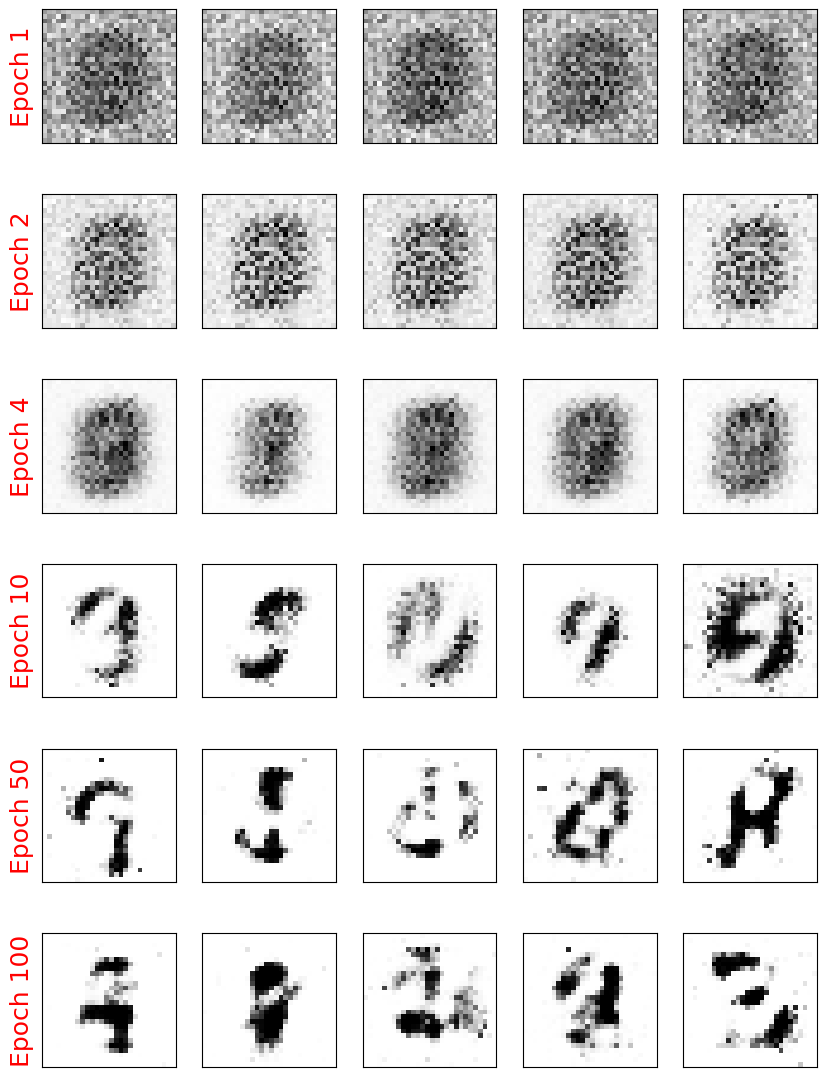

In [25]:
selected_epochs = [1, 2, 4, 10, 50, 100]
fig = plt.figure(figsize=(10, 14))
for i,e in enumerate(selected_epochs):
    for j in range(5):
        ax = fig.add_subplot(6, 5, i*5+j+1)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.text(-0.06, 0.5, f'Epoch {e}', rotation=90, size=18, color='red',
                    horizontalalignment='right', verticalalignment='center',
                    transform=ax.transAxes)
        image = epoch_samples[e-1][j]
        ax.imshow(image, cmap='gray_r')
plt.show()